# Customer Churn Prediction using XGBoost

<h2 style="font-size:28px;">Introduction</h2>

Customer churn refers to the phenomenon where customers discontinue using a company’s products or services. High churn rates directly impact revenue and long-term business sustainability. As a result, accurately identifying customers who are likely to churn is a critical problem for many organizations.

In this project, we build a **machine learning–based churn prediction system** that estimates the probability of a customer exiting the service. The goal is to enable businesses to take **proactive retention actions** such as personalized offers, improved customer support, or targeted engagement strategies.

We approach this problem using a **robust, end-to-end ML pipeline** with careful preprocessing, class imbalance handling, and evaluation using appropriate metrics for imbalanced classification.


## Project Objectives

The main objectives of this project are:

- Perform **Exploratory Data Analysis (EDA)** to understand customer behavior and churn patterns  
- Apply **appropriate preprocessing techniques** for numerical and categorical features  
- Handle **class imbalance** effectively to avoid biased predictions  
- Build a **reliable machine learning model** for churn prediction  
- Evaluate model performance using **ROC-AUC**, along with validation strategies  
- Provide insights that can support **data-driven business decisions**


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")



In [17]:
df = pd.read_csv('/kaggle/input/customer-churn-ng-intern/train.csv')

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (15000, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15724307.0,Ch'ang,717.0,France,Female,36.0,6.0,0.00,2.0,1.0,0.0,146875.86,0.0
1,1,15578980.0,Nnaife,594.0,Spain,Female,34.0,2.0,123971.16,1.0,1.0,1.0,137720.56,0.0
2,2,15603565.0,Onwuamaeze,645.0,Spain,Male,31.0,7.0,0.00,1.0,1.0,1.0,47852.74,0.0
3,3,15776631.0,Chidubem,551.0,Spain,Female,28.0,1.0,0.00,2.0,1.0,1.0,173844.89,0.0
4,4,15778368.0,Maclean,644.0,France,Male,27.0,10.0,0.00,1.0,1.0,0.0,157567.37,1.0


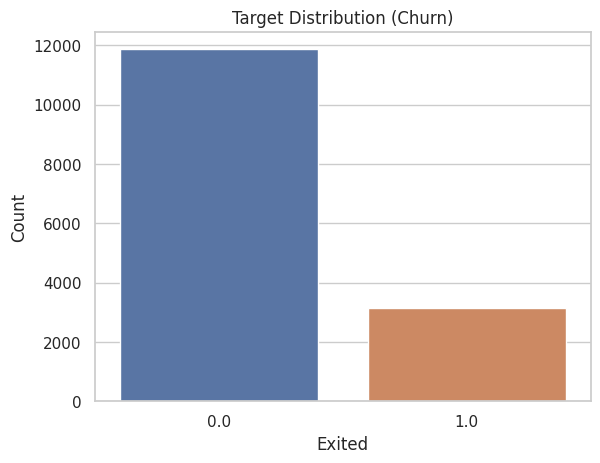

In [18]:
sns.countplot(x='Exited', data=df)
plt.title("Target Distribution (Churn)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()


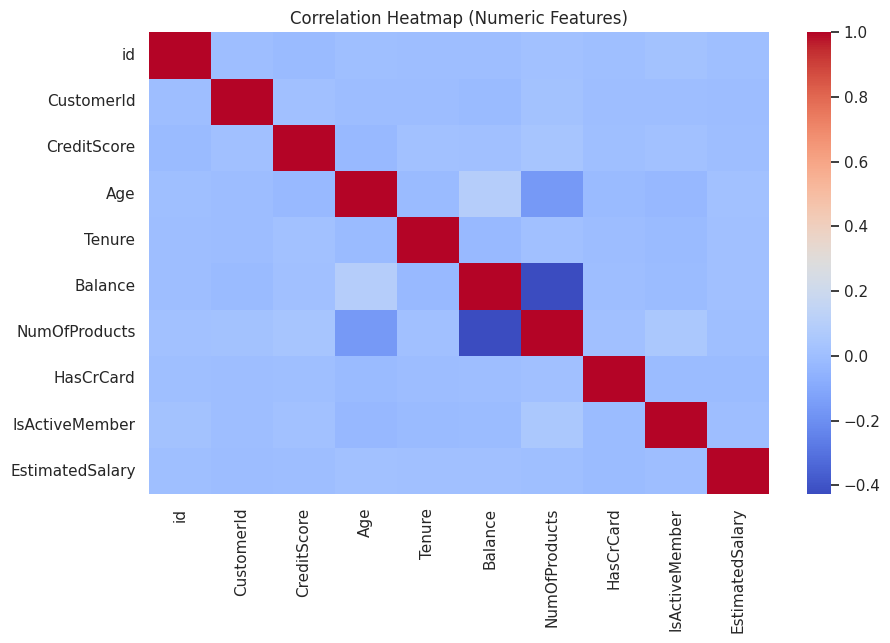

In [19]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Exited'], errors='ignore')

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [20]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(cat_cols))
print("Numerical columns:", list(num_cols))


Categorical columns: ['Surname', 'Geography', 'Gender']
Numerical columns: ['id', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [21]:
# scale numeric features and encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [23]:
# XGBoost pipeline with SMOTE to handle class imbalance
xgb_pipeline = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])


In [24]:
# Stratified cross-validation to preserve class distribution
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("XGBoost ROC-AUC scores:", roc_scores)
print("Mean ROC-AUC:", roc_scores.mean())


XGBoost ROC-AUC scores: [0.93475511 0.93071271 0.93049369 0.94172155 0.92884241]
Mean ROC-AUC: 0.9333050943259108


In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

xgb_pipeline.fit(X_train, y_train)

val_preds = xgb_pipeline.predict_proba(X_val)[:, 1]
print("Validation ROC-AUC:", roc_auc_score(y_val, val_preds))


Validation ROC-AUC: 0.9376990076198217


## Model Evaluation

The model performance was evaluated using **Stratified 5-Fold Cross-Validation**, ensuring that the class distribution was preserved across folds.

### Key Results:
- Mean Cross-Validation ROC-AUC: **~0.93**
- Validation ROC-AUC on hold-out set: **~0.94**

These results indicate that the model generalizes well and can effectively distinguish between churned and non-churned customers.


## Conclusion

In this project, we developed a robust customer churn prediction model using XGBoost and achieved strong predictive performance. The use of pipelines, proper handling of class imbalance, and stratified evaluation ensured a reliable and reproducible workflow.

### Future Improvements
- Perform systematic hyperparameter tuning in a separate experimentation notebook  
- Explore feature selection techniques to further simplify the model   
- Integrate model predictions into a real-time decision system for customer retention
